# Exploratory Data Analysis

In [2]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# general 
import numpy as np
import pandas as pd
import seaborn as sns

# Matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# scikit-learn 
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold

# lifelines imports
from lifelines.utils import concordance_index

# Boosting libraries imports
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import xgboost
import xgboost as xgb

import shap
import missingno as msno
from src.feature_engineering import FE
from src.config import CFG
import dataframe_image as dfi

In [3]:
# absolute paths to the data files
data_dir = os.path.join(project_root, 'data')
data_dict_path = os.path.join(data_dir, 'data_dictionary.csv')
sample_subm_path = os.path.join(data_dir, 'sample_submission.csv')
train_path = os.path.join(data_dir, 'train.csv')
test_path = os.path.join(data_dir, 'test.csv')

df_data_dict = pd.read_csv(data_dict_path)
df_sample_subm = pd.read_csv(sample_subm_path, index_col='ID')
df_train = pd.read_csv(train_path, index_col='ID')
df_test = pd.read_csv(test_path, index_col='ID')

In [4]:
with pd.option_context('display.max_colwidth', 1000):
    display(df_data_dict)

,variable,description,type,values
0,dri_score,Refined disease risk index,Categorical,['Intermediate' 'High' 'N/A - non-malignant indication' 'N/A - pediatric'\r\n 'High - TED AML case <missing cytogenetics' 'TBD cytogenetics' 'Low'\r\n 'Intermediate - TED AML case <missing cytogenetics'\r\n 'N/A - disease not classifiable' nan 'Very high' 'Missing disease status']
1,psych_disturb,Psychiatric disturbance,Categorical,['Yes' 'No' nan 'Not done']
2,cyto_score,Cytogenetic score,Categorical,['Intermediate' 'Favorable' 'Poor' 'TBD' nan 'Normal' 'Other' 'Not tested']
3,diabetes,Diabetes,Categorical,['No' 'Yes' nan 'Not done']
4,hla_match_c_high,Recipient / 1st donor allele level (high resolution) matching at HLA-C,Numerical,NaN
5,hla_high_res_8,"Recipient / 1st donor allele-level (high resolution) matching at HLA-A,-B,-C,-DRB1",Numerical,NaN
6,tbi_status,TBI,Categorical,"['No TBI' 'TBI + Cy +- Other' 'TBI +- Other, <=cGy' 'TBI +- Other, >cGy'\r\n 'TBI +- Other, -cGy, single' 'TBI +- Other, unknown dose'\r\n 'TBI +- Other, -cGy, unknown dose' 'TBI +- Other, -cGy, fractionated']"
7,arrhythmia,Arrhythmia,Categorical,['No' nan 'Yes' 'Not done']
8,hla_low_res_6,"Recipient / 1st donor antigen-level (low resolution) matching at HLA-A,-B,-DRB1",Numerical,NaN
9,graft_type,Graft type,Categorical,['Peripheral blood' 'Bone marrow']


In [5]:
df_sample_subm.head()

,prediction
ID,
28800,0.5
28801,0.5
28802,0.5


In [6]:
df_train.head()

,dri_score,psych_disturb,cyto_score,diabetes,hla_match_c_high,hla_high_res_8,tbi_status,arrhythmia,hla_low_res_6,graft_type,...,tce_div_match,donor_related,melphalan_dose,hla_low_res_8,cardiac,hla_match_drb1_high,pulm_moderate,hla_low_res_10,efs,efs_time
ID,,,,,,,,,,,,,,,,,,,,,
0,N/A - non-malignant indication,No,NaN,No,NaN,NaN,No TBI,No,6.0,Bone marrow,...,NaN,Unrelated,"N/A, Mel not given",8.0,No,2.0,No,10.0,0.0,42.356
1,Intermediate,No,Intermediate,No,2.0,8.0,"TBI +- Other, >cGy",No,6.0,Peripheral blood,...,Permissive mismatched,Related,"N/A, Mel not given",8.0,No,2.0,Yes,10.0,1.0,4.672
2,N/A - non-malignant indication,No,NaN,No,2.0,8.0,No TBI,No,6.0,Bone marrow,...,Permissive mismatched,Related,"N/A, Mel not given",8.0,No,2.0,No,10.0,0.0,19.793
3,High,No,Intermediate,No,2.0,8.0,No TBI,No,6.0,Bone marrow,...,Permissive mismatched,Unrelated,"N/A, Mel not given",8.0,No,2.0,No,10.0,0.0,102.349
4,High,No,NaN,No,2.0,8.0,No TBI,No,6.0,Peripheral blood,...,Permissive mismatched,Related,MEL,8.0,No,2.0,No,10.0,0.0,16.223


In [7]:
df_test.head()

,dri_score,psych_disturb,cyto_score,diabetes,hla_match_c_high,hla_high_res_8,tbi_status,arrhythmia,hla_low_res_6,graft_type,...,karnofsky_score,hepatic_mild,tce_div_match,donor_related,melphalan_dose,hla_low_res_8,cardiac,hla_match_drb1_high,pulm_moderate,hla_low_res_10
ID,,,,,,,,,,,,,,,,,,,,,
28800,N/A - non-malignant indication,No,NaN,No,NaN,NaN,No TBI,No,6.0,Bone marrow,...,90.0,No,NaN,Unrelated,"N/A, Mel not given",8.0,No,2.0,No,10.0
28801,Intermediate,No,Intermediate,No,2.0,8.0,"TBI +- Other, >cGy",No,6.0,Peripheral blood,...,90.0,No,Permissive mismatched,Related,"N/A, Mel not given",8.0,No,2.0,Yes,10.0
28802,N/A - non-malignant indication,No,NaN,No,2.0,8.0,No TBI,No,6.0,Bone marrow,...,90.0,No,Permissive mismatched,Related,"N/A, Mel not given",8.0,No,2.0,No,10.0


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28800 entries, 0 to 28799
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dri_score               28646 non-null  object 
 1   psych_disturb           26738 non-null  object 
 2   cyto_score              20732 non-null  object 
 3   diabetes                26681 non-null  object 
 4   hla_match_c_high        24180 non-null  float64
 5   hla_high_res_8          22971 non-null  float64
 6   tbi_status              28800 non-null  object 
 7   arrhythmia              26598 non-null  object 
 8   hla_low_res_6           25530 non-null  float64
 9   graft_type              28800 non-null  object 
 10  vent_hist               28541 non-null  object 
 11  renal_issue             26885 non-null  object 
 12  pulm_severe             26665 non-null  object 
 13  prim_disease_hct        28800 non-null  object 
 14  hla_high_res_6          23516 non-null  flo

In [9]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 28800 to 28802
Data columns (total 57 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dri_score               3 non-null      object 
 1   psych_disturb           3 non-null      object 
 2   cyto_score              1 non-null      object 
 3   diabetes                3 non-null      object 
 4   hla_match_c_high        2 non-null      float64
 5   hla_high_res_8          2 non-null      float64
 6   tbi_status              3 non-null      object 
 7   arrhythmia              3 non-null      object 
 8   hla_low_res_6           3 non-null      float64
 9   graft_type              3 non-null      object 
 10  vent_hist               3 non-null      object 
 11  renal_issue             3 non-null      object 
 12  pulm_severe             3 non-null      object 
 13  prim_disease_hct        3 non-null      object 
 14  hla_high_res_6          3 non-null      flo

In [10]:
df_train.describe()

,hla_match_c_high,hla_high_res_8,hla_low_res_6,hla_high_res_6,hla_high_res_10,hla_match_dqb1_high,hla_nmdp_6,hla_match_c_low,hla_match_drb1_low,hla_match_dqb1_low,...,age_at_hct,hla_match_a_low,hla_match_b_high,comorbidity_score,karnofsky_score,hla_low_res_8,hla_match_drb1_high,hla_low_res_10,efs,efs_time
count,24180.000000,22971.000000,25530.000000,23516.000000,21637.000000,23601.000000,24603.000000,26000.000000,26157.000000,24606.000000,...,28800.000000,26410.000000,24712.00000,28323.000000,27930.00000,25147.000000,25448.000000,23736.000000,28800.000000,28800.000000
mean,1.764516,6.876801,5.143322,5.109202,8.617230,1.736876,5.160346,1.757808,1.715296,1.773795,...,38.663162,1.709087,1.69962,1.702327,83.83208,6.903448,1.707128,8.664687,0.539306,23.237678
std,0.431941,1.564313,1.207757,1.214162,1.905125,0.447687,1.203240,0.435453,0.451282,0.427130,...,21.147581,0.458259,0.46518,1.994443,11.02884,1.565017,0.461179,1.882746,0.498461,24.799748
min,0.000000,2.000000,2.000000,0.000000,3.000000,0.000000,2.000000,0.000000,1.000000,0.000000,...,0.044000,0.000000,0.00000,0.000000,40.00000,2.000000,0.000000,4.000000,0.000000,0.333000
25%,2.000000,6.000000,4.000000,4.000000,7.000000,1.000000,4.000000,2.000000,1.000000,2.000000,...,19.539000,1.000000,1.00000,0.000000,70.00000,6.000000,1.000000,7.000000,0.000000,5.619750
50%,2.000000,8.000000,6.000000,6.000000,10.000000,2.000000,6.000000,2.000000,2.000000,2.000000,...,41.006000,2.000000,2.00000,1.000000,90.00000,8.000000,2.000000,10.000000,1.000000,9.796500
75%,2.000000,8.000000,6.000000,6.000000,10.000000,2.000000,6.000000,2.000000,2.000000,2.000000,...,55.965250,2.000000,2.00000,2.000000,90.00000,8.000000,2.000000,10.000000,1.000000,35.100000
max,2.000000,8.000000,6.000000,6.000000,10.000000,2.000000,6.000000,2.000000,2.000000,2.000000,...,73.726000,2.000000,2.00000,10.000000,100.00000,8.000000,2.000000,10.000000,1.000000,156.819000


In [11]:
df_test.describe()

,hla_match_c_high,hla_high_res_8,hla_low_res_6,hla_high_res_6,hla_high_res_10,hla_match_dqb1_high,hla_nmdp_6,hla_match_c_low,hla_match_drb1_low,hla_match_dqb1_low,...,donor_age,hla_match_b_low,age_at_hct,hla_match_a_low,hla_match_b_high,comorbidity_score,karnofsky_score,hla_low_res_8,hla_match_drb1_high,hla_low_res_10
count,2.0,2.0,3.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,...,1.00,3.0,3.000000,3.0,3.0,3.000000,3.0,3.0,3.0,3.0
mean,2.0,8.0,6.0,6.0,10.0,2.0,6.0,2.0,2.0,2.0,...,72.29,2.0,29.214667,2.0,2.0,1.000000,90.0,8.0,2.0,10.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,17.382119,0.0,0.0,1.732051,0.0,0.0,0.0,0.0
min,2.0,8.0,6.0,6.0,10.0,2.0,6.0,2.0,2.0,2.0,...,72.29,2.0,9.942000,2.0,2.0,0.000000,90.0,8.0,2.0,10.0
25%,2.0,8.0,6.0,6.0,10.0,2.0,6.0,2.0,2.0,2.0,...,72.29,2.0,21.969500,2.0,2.0,0.000000,90.0,8.0,2.0,10.0
50%,2.0,8.0,6.0,6.0,10.0,2.0,6.0,2.0,2.0,2.0,...,72.29,2.0,33.997000,2.0,2.0,0.000000,90.0,8.0,2.0,10.0
75%,2.0,8.0,6.0,6.0,10.0,2.0,6.0,2.0,2.0,2.0,...,72.29,2.0,38.851000,2.0,2.0,1.500000,90.0,8.0,2.0,10.0
max,2.0,8.0,6.0,6.0,10.0,2.0,6.0,2.0,2.0,2.0,...,72.29,2.0,43.705000,2.0,2.0,3.000000,90.0,8.0,2.0,10.0


In [ ]:
count_null_train = df_train.isnull().sum()
print(count_null_train)
percent_missing_col_train = round(count_null_train / len(df_train) * 100, 2)
print("Percentage of null values per train column:\n", percent_missing_col_train)

# pcts
total_cells_train = df_train.size
total_nulls_train = df_train.isnull().sum().sum()
percent_missing_train_total = round(total_nulls_train / total_cells_train * 100, 2)
print("\nPercentage of total null values in DataFrame:", percent_missing_train_total)

dri_score                   154
psych_disturb              2062
cyto_score                 8068
diabetes                   2119
hla_match_c_high           4620
hla_high_res_8             5829
tbi_status                    0
arrhythmia                 2202
hla_low_res_6              3270
graft_type                    0
vent_hist                   259
renal_issue                1915
pulm_severe                2135
prim_disease_hct              0
hla_high_res_6             5284
cmv_status                  634
hla_high_res_10            7163
hla_match_dqb1_high        5199
tce_imm_match             11133
hla_nmdp_6                 4197
hla_match_c_low            2800
rituximab                  2148
hla_match_drb1_low         2643
hla_match_dqb1_low         4194
prod_type                     0
cyto_score_detail         11923
conditioning_intensity     4789
ethnicity                   587
year_hct                      0
obesity                    1760
mrd_hct                   16597
in_vivo_

In [ ]:
count_null_test = df_test.isnull().sum()
print(count_null_test)
percent_missing_col_test = round(count_null_test / len(df_test) * 100, 2)
print("Percentage of null values per test column:\n", percent_missing_col_test)

# pct of total null values in the test DataFrame
total_cells_test = df_test.size
total_nulls_test = df_test.isnull().sum().sum()
percent_missing_test_total = round(total_nulls_test / total_cells_test * 100, 2)
print("\nPercentage of total null values in DataFrame:", percent_missing_test_total)

dri_score                 0
psych_disturb             0
cyto_score                2
diabetes                  0
hla_match_c_high          1
hla_high_res_8            1
tbi_status                0
arrhythmia                0
hla_low_res_6             0
graft_type                0
vent_hist                 0
renal_issue               0
pulm_severe               0
prim_disease_hct          0
hla_high_res_6            0
cmv_status                0
hla_high_res_10           1
hla_match_dqb1_high       0
tce_imm_match             1
hla_nmdp_6                0
hla_match_c_low           0
rituximab                 0
hla_match_drb1_low        0
hla_match_dqb1_low        0
prod_type                 0
cyto_score_detail         2
conditioning_intensity    2
ethnicity                 0
year_hct                  0
obesity                   0
mrd_hct                   2
in_vivo_tcd               0
tce_match                 2
hla_match_a_high          0
hepatic_severe            0
donor_age           

In [ ]:
# summary table
summary_stats = df_train.describe(include='number').T
summary_stats['missing_pct'] = 100 * df_train.isnull().sum() / len(df_train)
summary_stats = summary_stats[['count', 'missing_pct', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary_stats = summary_stats.round(2)

# export top 10 rows as PNG using selenium 
dfi.export(summary_stats.head(10), 'summary_stats.png', table_conversion='selenium')

<Axes: >

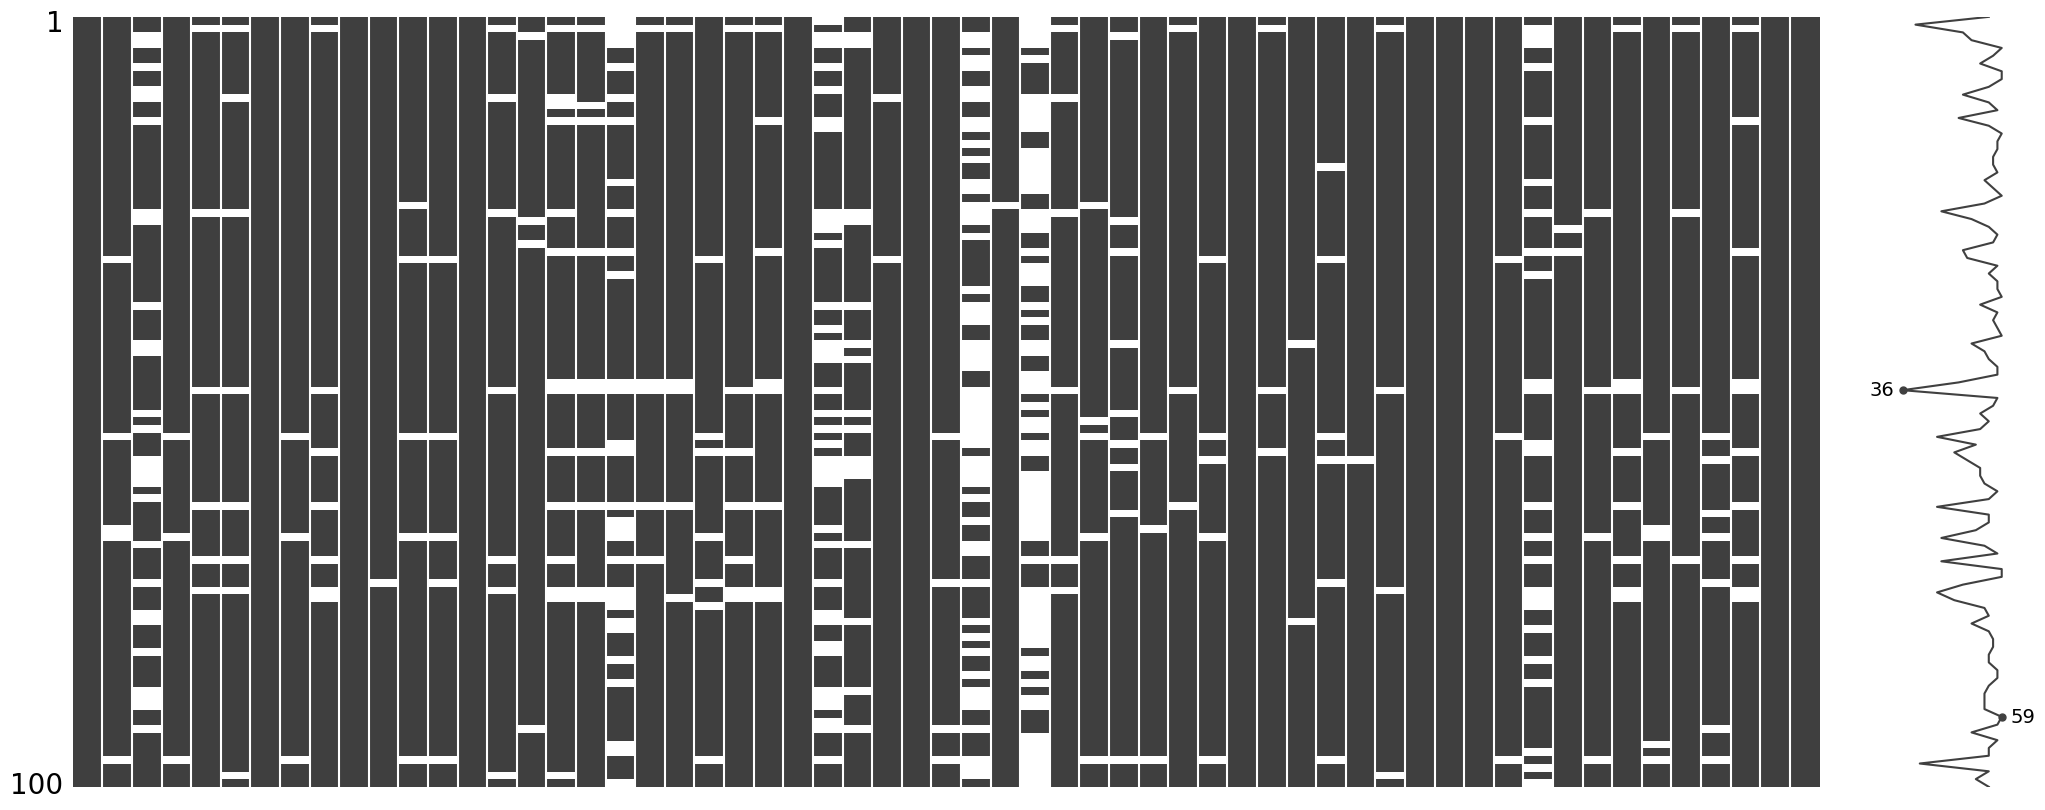

In [15]:
msno.matrix(df_train.sample(100)) 

# Race group distribution
In the training data, there are six race groups with about 4800 samples each.

In [16]:
features = [f for f in df_test.columns if f != 'ID']
cat_features = list(df_train.select_dtypes(object).columns)
df_train[cat_features] = df_train[cat_features].astype(str).astype('category')
race_groups = np.unique(df_train.race_group)

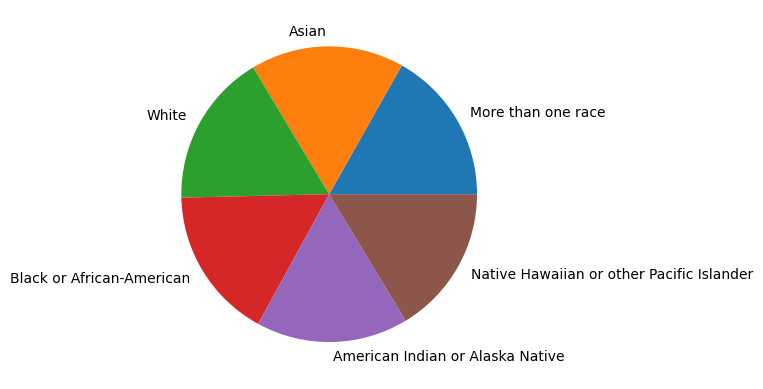

In [17]:
rg = df_train.race_group.value_counts()
plt.pie(rg, labels=rg.index)
plt.savefig('pie_chart.png')
plt.show()


# Age distribution

There are only two features with continuous data, donor age and patient age. The patient age histogram shows that the patient age distribution has five modes. Such a distribution is unnatural and must be an artifact of the synthetic data generation.

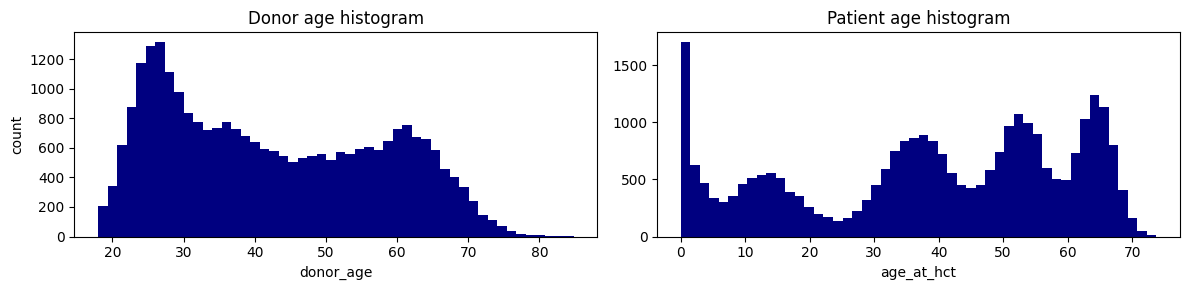

In [18]:
plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.hist(df_train.donor_age, bins=50, color='navy')
plt.title('Donor age histogram')
plt.xlabel('donor_age')
plt.ylabel('count')
plt.subplot(1, 2, 2)
plt.title('Patient age histogram')
plt.hist(df_train.age_at_hct, bins=50, color='navy')
plt.xlabel('age_at_hct')
plt.tight_layout()
plt.savefig('age_hist.png')
plt.show()

My first thought was that different race groups had different modes, but the patient age distribution has the same five modes in every race group:

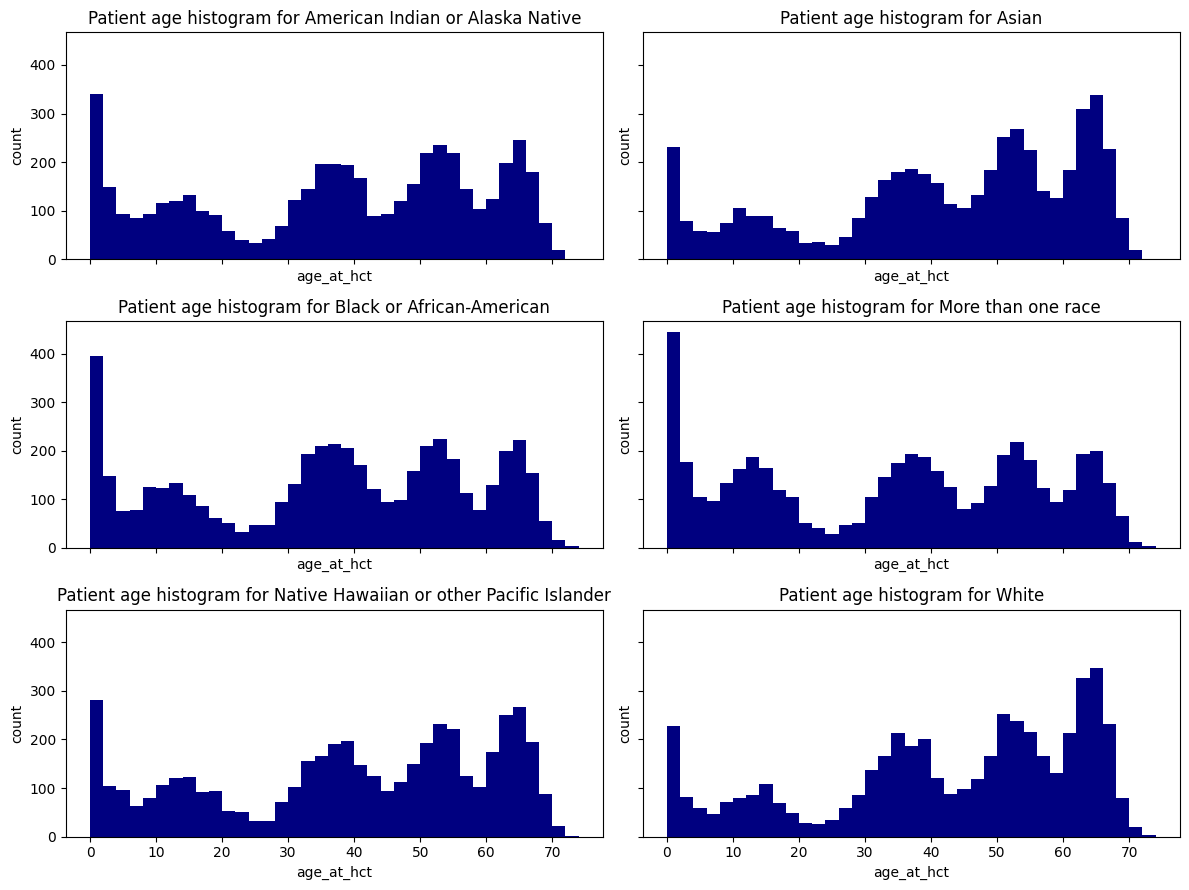

In [19]:
_, axs = plt.subplots(3, 2, sharex=True, sharey=True, figsize=(12, 9))
for race_group, ax in zip(race_groups, axs.ravel()):
    ax.hist(df_train.age_at_hct[df_train.race_group == race_group],
            bins=np.linspace(0, 74, 38),
            color='navy')
    ax.set_title(f'Patient age histogram for {race_group}')
    ax.set_xlabel('age_at_hct')
    ax.set_ylabel('count')
plt.tight_layout()
plt.savefig('age_hist_race_stratified.png')
plt.show()

The age of 0.044 years (16 days) occurs 1005 times in the training dataset, which is odd. I would not expect a newborn to undergo HCT treatment. 

In [20]:
df_train.age_at_hct.value_counts().sort_values(ascending=False).head()

age_at_hct
0.044     1005
15.820       6
64.470       6
31.938       5
62.164       5
Name: count, dtype: int64

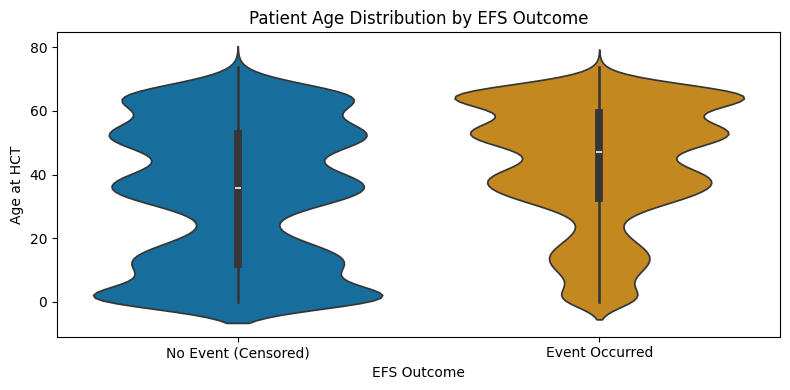

In [21]:
plt.figure(figsize=(8, 4))
sns.violinplot(x='efs', y='age_at_hct', hue='efs', data=df_train, palette='colorblind', legend=False)
plt.xticks([0, 1], ['No Event (Censored)', 'Event Occurred'])
plt.title("Patient Age Distribution by EFS Outcome")
plt.xlabel("EFS Outcome")
plt.ylabel("Age at HCT")
plt.tight_layout()
plt.savefig("violin_age_by_efs.png")
plt.show()

# EFS_time Target

The prediction target consists of two parts:

- efs_time, always positive, measured in months
- efs, always zero or one, indicates the presence or absence of an event:
    - efs=1 means "patient had event exactly at time efs_time
    - efs=0 means "patient has had no event at time efs_time

This situation is called "censored data": Samples of which we know the time of event are uncensored, and if we only know a lower bound for the time of event, the sample is (right-)censored.

Censoring is the reason this competition has a special metric and that we need specific models. The competition is a regression task, but we know y_true for only half the samples. For the other (censored) half, all we know is lower bounds for y_true. One cannot compute a squared error based on y_true > 100 and y_pred == 120. RMSE and similar metrics cannot deal with that.


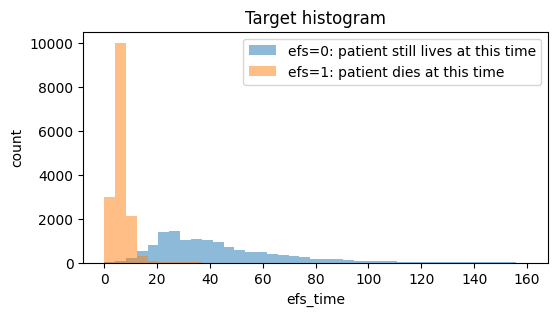

In [22]:
plt.figure(figsize=(6, 3))
plt.hist(df_train.efs_time[df_train.efs == 0], bins=np.linspace(0, 160, 40), label='efs=0: patient still lives at this time', alpha=0.5)
plt.hist(df_train.efs_time[df_train.efs == 1], bins=np.linspace(0, 160, 40), label='efs=1: patient dies at this time', alpha=0.5)
plt.legend()
plt.xlabel('efs_time')
plt.ylabel('count')
plt.title('Target histogram')
plt.savefig('target_hist.png')
plt.show()

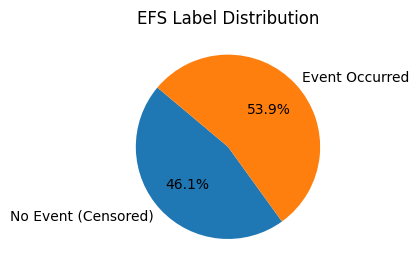

In [ ]:
labels = ['No Event (Censored)', 'Event Occurred']
sizes = df_train['efs'].value_counts(normalize=True).sort_index() * 100
colors = ['#1f77b4', '#ff7f0e']

plt.figure(figsize=(4, 4))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('EFS Label Distribution')
plt.tight_layout()
plt.savefig("efs_pie.png")
plt.show()

Survival function and cumulative hazard function

The survival function shows how many patients survive for how long (Wikipedia: Kaplan–Meier estimator). At month 0, 100 % of the patients live. At month 20, only 40 % – 60 % remain, depending on their race group. Patients with "more than one race" have the highest probability of survival, whites the lowest. For those who are used to working with cumulative density functions (cdf) of probability distributions, the survival function is nothing else than a top–down mirrored cdf of the time-of-event probability distribution. The cumulative hazard is another representation of the same facts; it corresponds to the negative logarithm of the survival function (Wikipedia: Nelson–Aalen estimator).


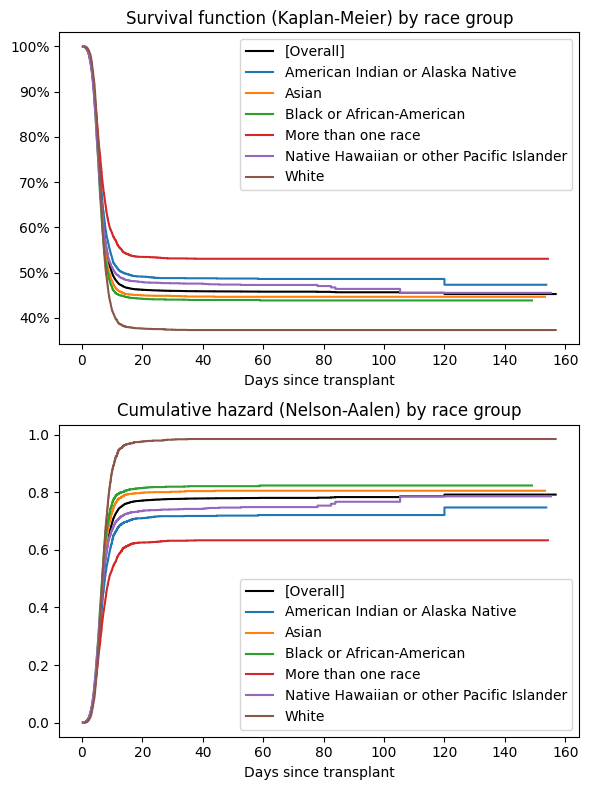

In [24]:
def survival_function(df):
    survival_df = df[['efs', 'efs_time']].groupby('efs_time').agg(['size', 'sum']).droplevel(0, axis=1).astype(int)
    survival_df['n_at_risk'] = survival_df['size'].sum() - survival_df['size'].shift().fillna(0).cumsum().astype(int)
    hazard = survival_df['sum'] / survival_df['n_at_risk'] 
    survival_df['cumulative_hazard'] = np.cumsum(hazard) # nelson_aalen_estimator
    survival_df['survival_probability'] = (1 - hazard).cumprod() # kaplan_meier_estimator
    return survival_df

plt.figure(figsize=(6, 8))

plt.subplot(2, 1, 1)
survival_df = survival_function(df_train)
plt.step(survival_df.index, survival_df['survival_probability'], c='k', where="post", label='[Overall]')
plt.xlabel('Days since transplant')
for race_group in race_groups:
    subset = df_train.query('race_group == @race_group')
    survival_df = survival_function(subset)
    plt.step(survival_df.index, survival_df['survival_probability'], where="post", label=race_group)
plt.xlabel('Days since transplant')
plt.legend(loc='upper right')
plt.title('Survival function (Kaplan-Meier) by race group')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0)) # percent of xmax

plt.subplot(2, 1, 2)
survival_df = survival_function(df_train)
plt.step(survival_df.index, survival_df['cumulative_hazard'], c='k', where="post", label='[Overall]')
plt.xlabel('Days since transplant')
for race_group in race_groups:
    subset = df_train.query('race_group == @race_group')
    survival_df = survival_function(subset)
    plt.step(survival_df.index, survival_df['cumulative_hazard'], where="post", label=race_group)
plt.xlabel('Days since transplant')
plt.legend(loc='lower right')
plt.title('Cumulative hazard (Nelson-Aalen) by race group')

plt.tight_layout()
plt.savefig('KM_NA_functions.png')
plt.show()

# Class Balance for efs (event occurred vs. censored)

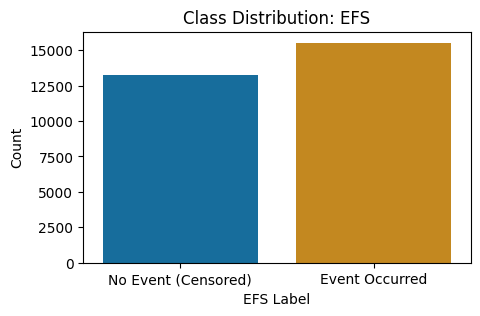

In [25]:
plt.figure(figsize=(5, 3))
sns.countplot(x='efs', data=df_train, hue='efs', palette='colorblind', legend=False)
plt.title('Class Distribution: EFS')
plt.xticks([0, 1], ['No Event (Censored)', 'Event Occurred'])
plt.ylabel('Count')
plt.xlabel('EFS Label')
plt.savefig('class_dist.png')
plt.show()

# Event Rate by Feature

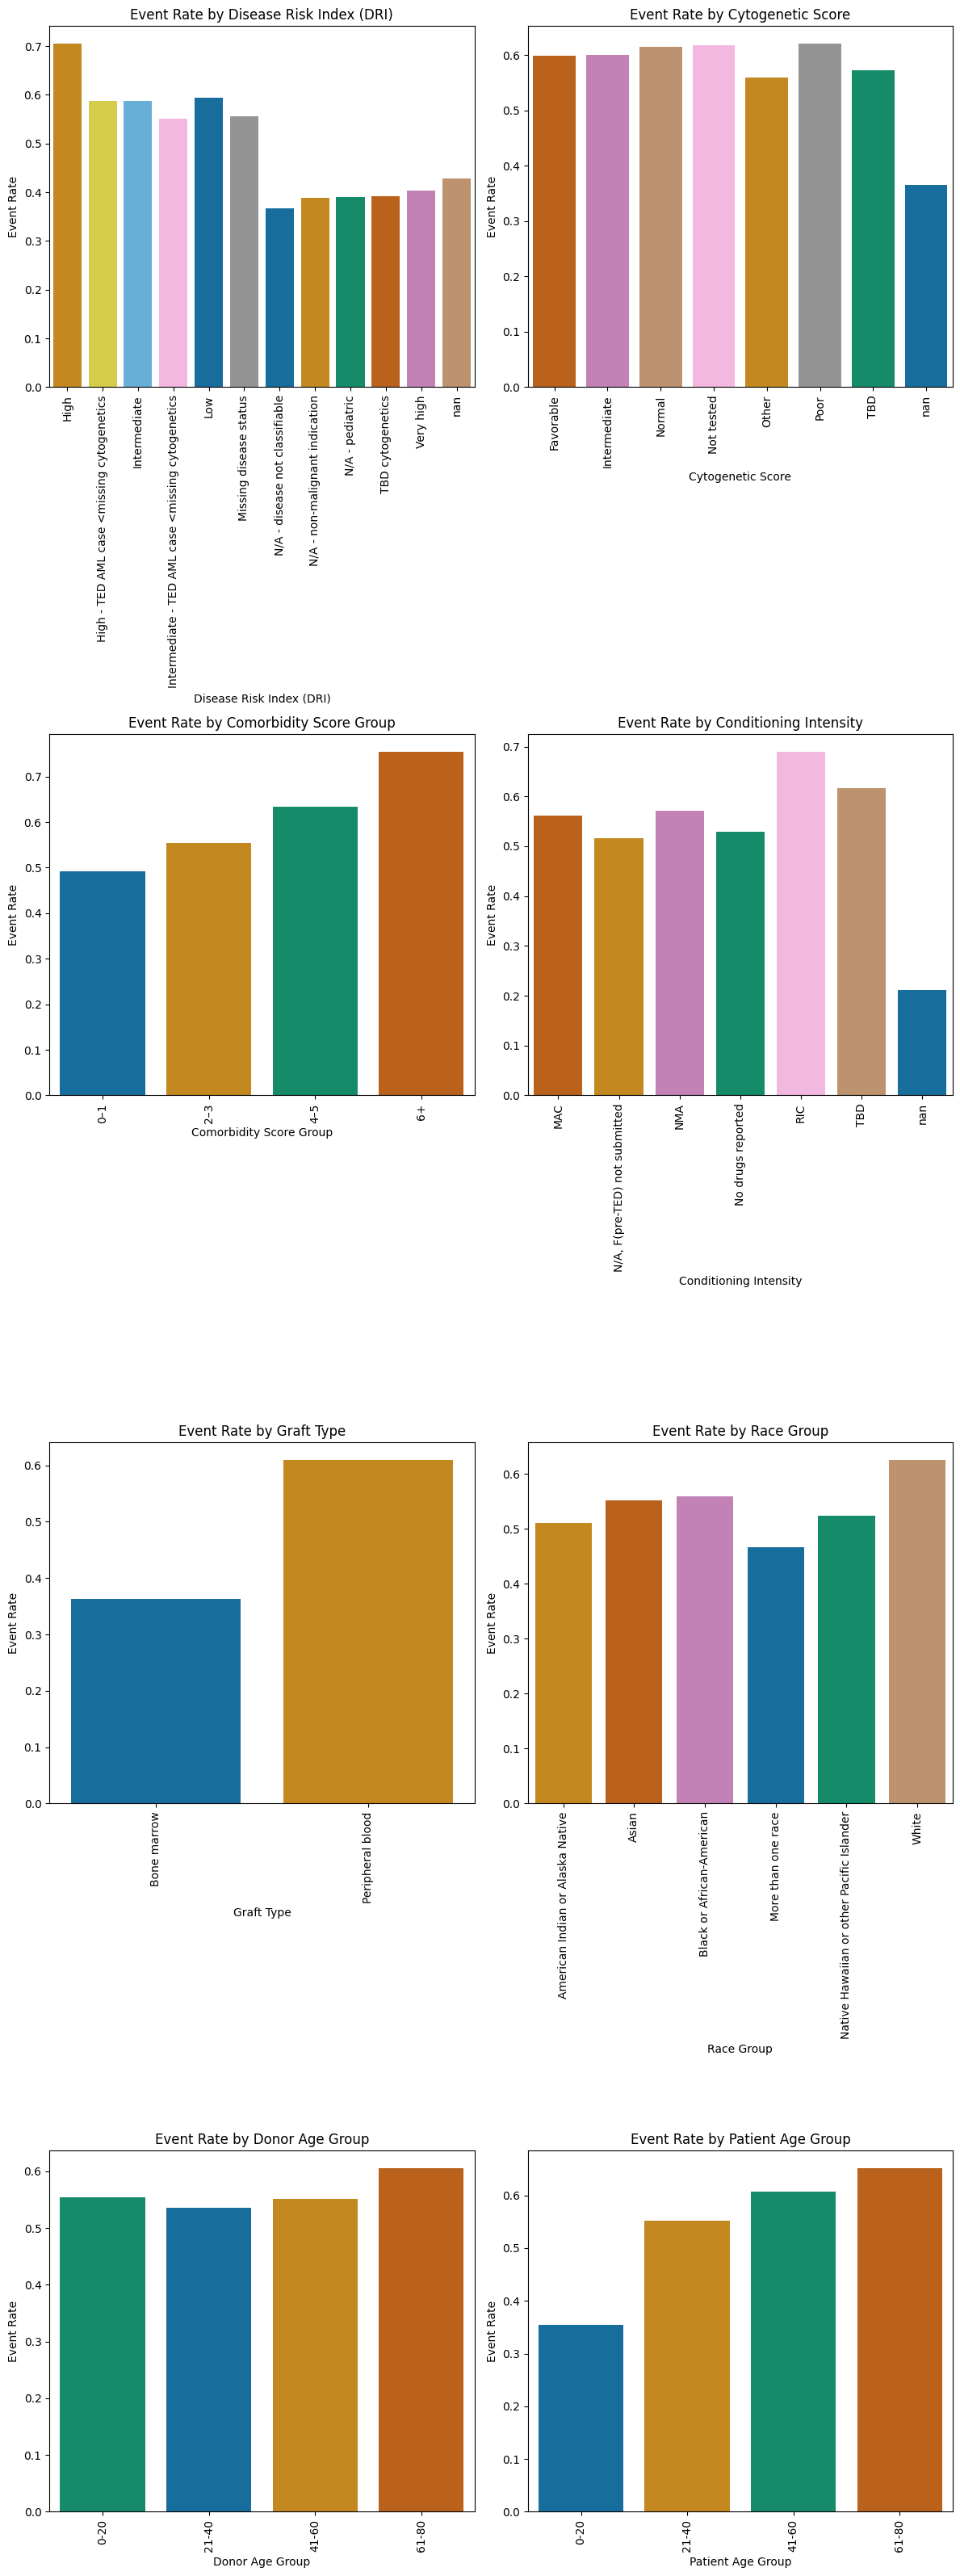

In [ ]:
event_rate_race = df_train.groupby('race_group')['efs'].mean().sort_values(ascending=False)
event_rate_dri = df_train.groupby('dri_score')['efs'].mean().sort_values(ascending=False)
event_rate_cyto = df_train.groupby('cyto_score')['efs'].mean().sort_values(ascending=False)
event_rate_graft = df_train.groupby('graft_type')['efs'].mean()
event_rate_conditioning = df_train.groupby('conditioning_intensity')['efs'].mean().sort_values(ascending=False)
df_train['comorbidity_bin'] = pd.cut(df_train['comorbidity_score'], bins=[-1, 1, 3, 5, 10], labels=['0–1', '2–3', '4–5', '6+'])
event_rate_comorb = df_train.groupby('comorbidity_bin')['efs'].mean()
df_train['age_bins'] = pd.cut(df_train['donor_age'], bins=[0, 20, 40, 60, 80], labels=['0-20', '21-40', '41-60', '61-80'])
event_rate_donor_age = df_train.groupby('age_bins')['efs'].mean()
df_train['age_bins'] = pd.cut(df_train['age_at_hct'], bins=[0, 20, 40, 60, 80], labels=['0-20', '21-40', '41-60', '61-80'])
event_rate_age = df_train.groupby('age_bins')['efs'].mean()

fig, axes = plt.subplots(4, 2, figsize=(12, 32))
axes = axes.flatten()

plots = [
    ('Disease Risk Index (DRI)', event_rate_dri),
    ('Cytogenetic Score', event_rate_cyto),
    ('Comorbidity Score Group', event_rate_comorb),
    ('Conditioning Intensity', event_rate_conditioning),
    ('Graft Type', event_rate_graft),
    ('Race Group', event_rate_race),
    ('Donor Age Group', event_rate_donor_age),
    ('Patient Age Group', event_rate_age),
]

for ax, (title, data) in zip(axes, plots):
    sns.barplot(x=data.index, y=data.values, hue=data.values, palette='colorblind', legend=False, ax=ax)
    ax.set_title(f'Event Rate by {title}')
    ax.set_ylabel('Event Rate')
    ax.set_xlabel(title)
    ax.tick_params(axis='x', rotation=90)

# hide unused subplots
for i in range(len(plots), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('event_rate_by_feat.png')
plt.show()

# Correlation Matrix
This gives a quick view of linear relationships and helps motivate regression modeling.

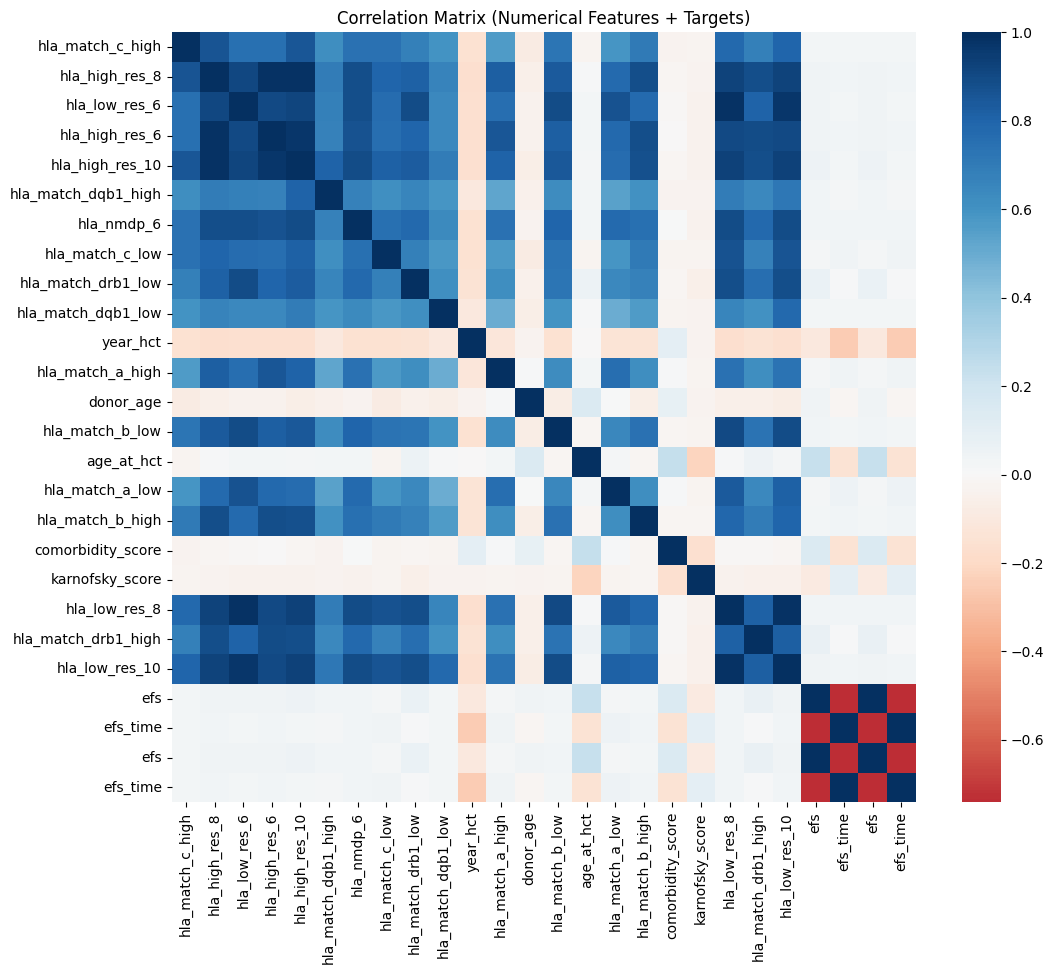

In [ ]:
# subset numerical features
num_cols = df_train.select_dtypes(include='number').columns

corr_matrix = df_train[num_cols + ['efs', 'efs_time']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='RdBu', center=0, annot=False)
plt.title('Correlation Matrix (Numerical Features + Targets)')
plt.savefig('corr_matrix.png')
plt.show()

# SHAP (TreeExplainer) Feature Importances

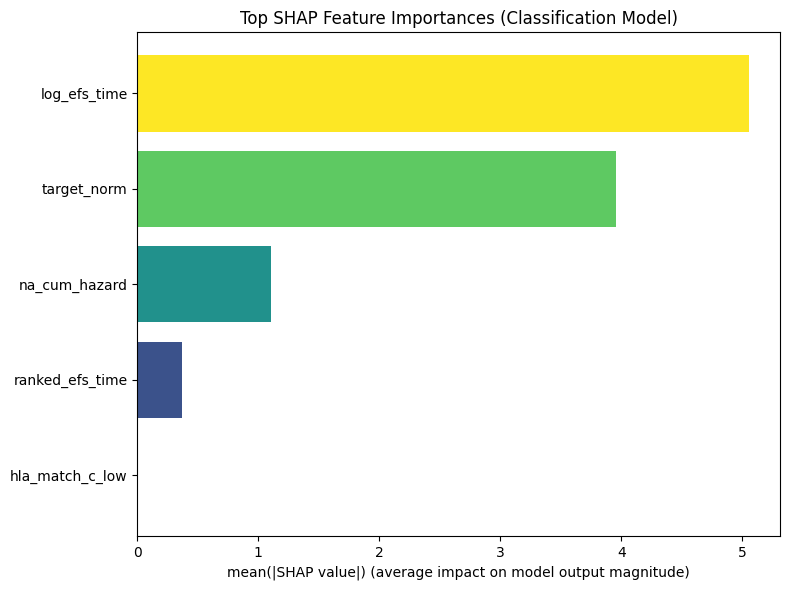

In [ ]:
# feature engineering
fe = FE(batch_size=CFG.batch_size)
processed = fe.feature_engineering_pipeline(CFG.train_path, model_type="tree", train=True)

X_cls = processed['X']
y_cls = processed['efs']  

# drop NaNs
X_cls = X_cls.dropna(axis=1)
clf_model = xgb.XGBClassifier(n_estimators=700, max_depth=8, eval_metric='logloss', enable_categorical=True)
clf_model.fit(X_cls, y_cls)

# SHAP explainer
explainer = shap.Explainer(clf_model)
shap_values = explainer(X_cls)

# get top N features by mean(|SHAP|) value
TOP_N = 5
mean_shap = np.abs(shap_values.values).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[-TOP_N:]
sorted_features = X_cls.columns[sorted_idx]
sorted_shap = mean_shap[sorted_idx]
colors = plt.cm.viridis(np.linspace(0, 1, TOP_N))

plt.figure(figsize=(8, 6))
plt.barh(sorted_features, sorted_shap, color=colors)
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.title("Top SHAP Feature Importances (Classification Model)")
plt.tight_layout()
plt.savefig('SHAP_cls.png')
plt.show()

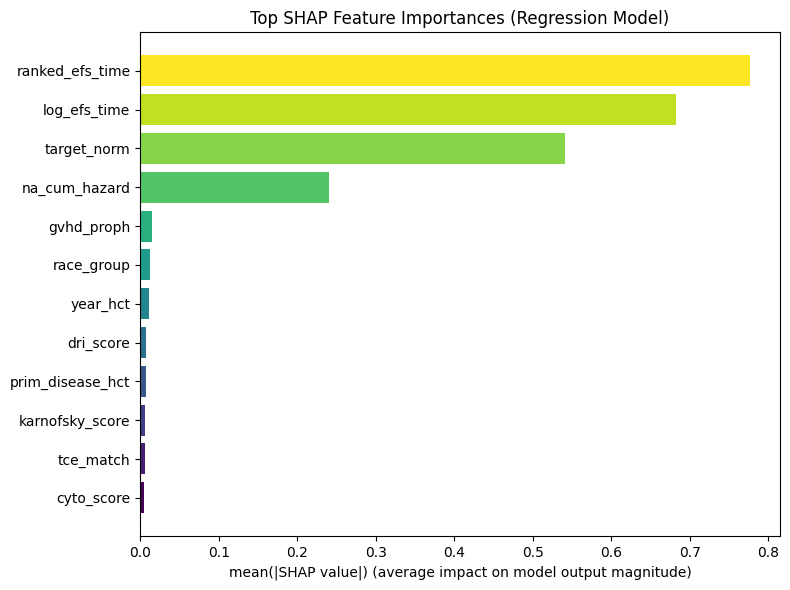

In [ ]:
X_all = processed['X']
y_cls = processed['efs']          
y_reg = processed['efs_time']    
cat_cols_tree = processed['feature_cat']

uncensored_idx = y_cls == 1
X_reg = X_all[uncensored_idx]
y_reg_filtered = y_reg[uncensored_idx]
X_reg = X_reg.dropna(axis=1)


reg_model = xgb.XGBRegressor(n_estimators=700, max_depth=8, enable_categorical=True)
reg_model.fit(X_reg, y_reg_filtered)

# SHAP explainer
explainer = shap.Explainer(reg_model)
shap_values = explainer(X_reg)

# custom bar coloring
mean_shap = np.abs(shap_values.values).mean(axis=0)
sorted_idx = np.argsort(mean_shap)
sorted_features = X_reg.columns[sorted_idx]
sorted_shap = mean_shap[sorted_idx]

# set number of features to display
TOP_N = 12
sorted_idx = np.argsort(mean_shap)[-TOP_N:]
sorted_features = X_reg.columns[sorted_idx]
sorted_shap = mean_shap[sorted_idx]
colors = plt.cm.viridis(np.linspace(0, 1, TOP_N))

plt.figure(figsize=(8, 6))
plt.barh(sorted_features, sorted_shap, color=colors)
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.title("Top SHAP Feature Importances (Regression Model)")
plt.tight_layout()
plt.savefig('SHAP_reg.png')
plt.show()

## SHAP Insights Summary

### **Stage 1: Classification Model (EFS Event Risk)**

**Top predictors of binary event occurrence:**

* **`log_efs_time`**: This engineered feature dominates importance.
* **`target_norm`** and **`ranked_efs_time`**: Also engineered proxies for survival time. Their strong presence suggests the classifier is partially relying on pre-baked survival characteristics.
* **`km_survival_prob`**: This proxy from Kaplan–Meier estimates encodes population-level risk, a strong clinical signal.
* **`hla_match_c_low`**: The only true biological feature among the top 5, indicating HLA matching may modestly influence risk of relapse or death.

> **Insight**: Model relies heavily on engineered time features. A follow-up experiment could test predictive power when these are removed to isolate clinical contributors.


### **Stage 2: Regression Model (Time to Event Prediction)**

**Top predictors of actual survival time among patients who experienced an event:**

* **`log_efs_time`, `ranked_efs_time`, `km_survival_prob`** again top the list, they are naturally correlated with the target but may still carry meaningful order/ranking for survival.
* **`gvhd_proph`, `race_group`, `year_hct`, `dri_score`, `prim_disease_hct`**: These are **true clinical covariates** and start to show up meaningfully in the regression setting. Their appearance suggests the model is beginning to rely more on transplant-specific risk factors when actual time predictions are made.
* **`karnofsky_score`** and **`tce_match`** round out the top 10, these are known in the clinical domain to be associated with transplant outcomes.

> **Insight**: Unlike classification, the regression model surfaces more **biological and procedural factors**, aligning better with expected clinical relevance.


### Overall Implication

* Engineered features dominate prediction in both stages, this is helpful for performance but may mask interpretability.
* Real-world transplant features (HLA match, disease status, conditioning) become more important in regression, which aligns well with survival modeling goals.


In [30]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_fold_race_scores = {}
all_fold_overall_scores = []

def evaluate_fold(y_pred, fold, df_val, time, event_observed):
    """
    Evaluates the performance of the model on a single fold, broken down by race group.
    Args:
        y_pred (np.array): Predicted hazard scores for the validation set.
        fold (int): The current fold number.
        df_val (pd.DataFrame): The validation portion of the DataFrame.
        time (np.array): Absolute time to event (or censoring).
        event_observed (np.array): Event indicator (1 if event occurred, 0 if censored).
    """
    print(f"\nFold {fold+1}:")
    fold_race_scores = {}

    for race in df_val['race_group'].unique():
        mask = df_val['race_group'] == race
        y_pred_race = y_pred[mask]
        time_race = time[mask]
        event_observed_race = event_observed[mask]

        if len(event_observed_race) > 0:
            c_index_race = concordance_index(time_race, -y_pred_race, event_observed_race)
            fold_race_scores[race] = c_index_race
            print(f"  {race}: {c_index_race:.3f}", end=" ")
        else:
            fold_race_scores[race] = np.nan
            print(f"  {race}: NaN", end=" ")

    overall_c_index = concordance_index(time, -y_pred, event_observed)
    print(f"  Overall: {overall_c_index:.3f}")

    all_fold_race_scores[fold] = fold_race_scores
    all_fold_overall_scores.append(overall_c_index)

def display_overall(model_name):
    """
    Displays the overall performance of the model across all folds and race groups as a heatmap
    """
    race_groups = processed['race_group'].unique()
    num_folds = len(all_fold_race_scores)
    heatmap_data = np.zeros((num_folds, len(race_groups) + 1))
    race_labels = list(race_groups) + ["Overall"]

    for fold in range(num_folds):
        fold_scores = all_fold_race_scores[fold]
        for i, race in enumerate(race_groups):
            heatmap_data[fold, i] = fold_scores.get(race, np.nan)
        heatmap_data[fold, len(race_groups)] = all_fold_overall_scores[fold]

    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis",
                yticklabels=[f"Fold {i+1}" for i in range(num_folds)],
                xticklabels=race_labels, cbar_kws={'label': 'C-index'})
    plt.title(f"{model_name} Performance by Race Group and Fold")
    plt.ylabel("Fold")
    plt.xlabel("Race Group")
    plt.tight_layout()
    plt.show()

    # Means and stds
    mean_scores = {race: np.nanmean([all_fold_race_scores[f].get(race, np.nan) for f in range(num_folds)]) for race in race_groups}
    overall_mean = np.mean(all_fold_overall_scores)
    std_scores = {race: np.nanstd([all_fold_race_scores[f].get(race, np.nan) for f in range(num_folds)]) for race in race_groups}
    overall_std = np.std(all_fold_overall_scores)

    print("\nMean C-index by Race Group:")
    for race, mean_c in mean_scores.items():
        print(f"  {race}: {mean_c:.3f}")
    print(f"  Overall Mean: {overall_mean:.3f}")

    print("\nStandard Deviation of C-index by Race Group:")
    for race, std_c in std_scores.items():
        print(f"  {race}: {std_c:.3f}")
    print(f"  Overall Std: {overall_std:.3f}")

Leaky columns in X_all: []

Fold 1:
  5: 0.664   3: 0.693   1: 0.695   0: 0.685   2: 0.695   4: 0.680   Overall: 0.686

Fold 2:
  3: 0.685   4: 0.687   1: 0.707   5: 0.662   2: 0.675   0: 0.703   Overall: 0.687

Fold 3:
  0: 0.689   5: 0.669   3: 0.701   4: 0.676   2: 0.680   1: 0.699   Overall: 0.687

Fold 4:
  1: 0.703   3: 0.682   5: 0.677   0: 0.700   2: 0.664   4: 0.670   Overall: 0.683

Fold 5:
  0: 0.675   4: 0.671   3: 0.676   5: 0.679   1: 0.684   2: 0.668   Overall: 0.676


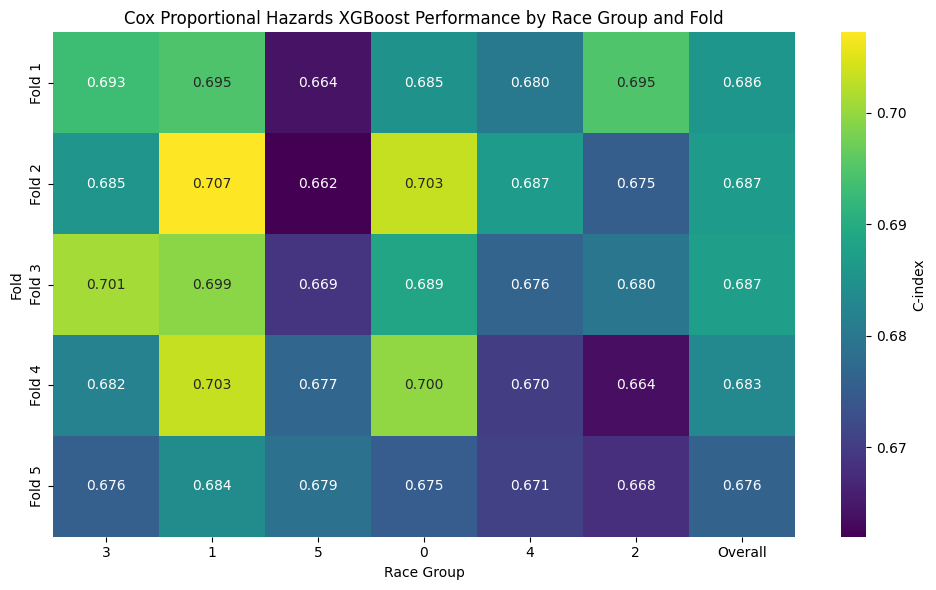


Mean C-index by Race Group:
  3: 0.687
  1: 0.698
  5: 0.670
  0: 0.690
  4: 0.677
  2: 0.676
  Overall Mean: 0.684

Standard Deviation of C-index by Race Group:
  3: 0.009
  1: 0.008
  5: 0.007
  0: 0.010
  4: 0.006
  2: 0.011
  Overall Std: 0.004


In [ ]:
X_all = processed['X']
# clean features --> drop any remaining leakage
X_all = X_all.drop(columns=['efs', 'efs_time', 'log_efs_time', 'ranked_efs_time', 'race_group',
                            'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm'],
                   errors='ignore')

print("Leaky columns in X_all:", [col for col in X_all.columns if 'efs' in col or 'survival' in col or 'hazard' in col or 'rank' in col])

y_cls = processed['efs']
y_reg = processed['efs_time']
race_groups = processed['race_group'] # directly from processed
cat_cols = processed['feature_cat']

# survival target (positive = event, negative = censored)
y_surv = np.where(y_cls == 1, y_reg, -y_reg)

xgb_cox_params = {
    'objective': 'survival:cox',
    'grow_policy': 'depthwise',
    'n_estimators': 700,
    'learning_rate': 0.0254,
    'max_depth': 8,
    'reg_lambda': 0.116,
    'reg_alpha': 0.139,
    'min_child_weight': 23.8,
    'colsample_bytree': 0.59,
    'subsample': 0.7,
    'tree_method': 'hist',
    'enable_categorical': True,
    'seed': 42
}

# CV evaluation
all_fold_race_scores = {}
all_fold_overall_scores = []

for fold, (idx_tr, idx_va) in enumerate(kf.split(X_all, race_groups)):
    X_tr = X_all.iloc[idx_tr]
    X_va = X_all.iloc[idx_va]
    y_tr = y_surv[idx_tr]
    y_va = y_surv[idx_va]

    model = xgb.XGBRegressor(**xgb_cox_params)
    model.fit(X_tr, y_tr)

    y_va_pred = model.predict(X_va)

    df_val = pd.DataFrame({'race_group': race_groups.iloc[idx_va].values})
    evaluate_fold(
        y_pred=y_va_pred,
        fold=fold,
        df_val=df_val,
        time=np.abs(y_va),
        event_observed=y_cls.iloc[idx_va].values
    )

display_overall("Cox Proportional Hazards XGBoost")


Fold 1:
  5: 0.652   3: 0.692   1: 0.688   0: 0.681   2: 0.691   4: 0.684   Overall: 0.682

Fold 2:
  3: 0.692   4: 0.683   1: 0.705   5: 0.657   2: 0.676   0: 0.701   Overall: 0.686

Fold 3:
  0: 0.695   5: 0.673   3: 0.697   4: 0.679   2: 0.681   1: 0.695   Overall: 0.688

Fold 4:
  1: 0.705   3: 0.677   5: 0.675   0: 0.695   2: 0.654   4: 0.671   Overall: 0.680

Fold 5:
  0: 0.681   4: 0.665   3: 0.668   5: 0.668   1: 0.684   2: 0.664   Overall: 0.673


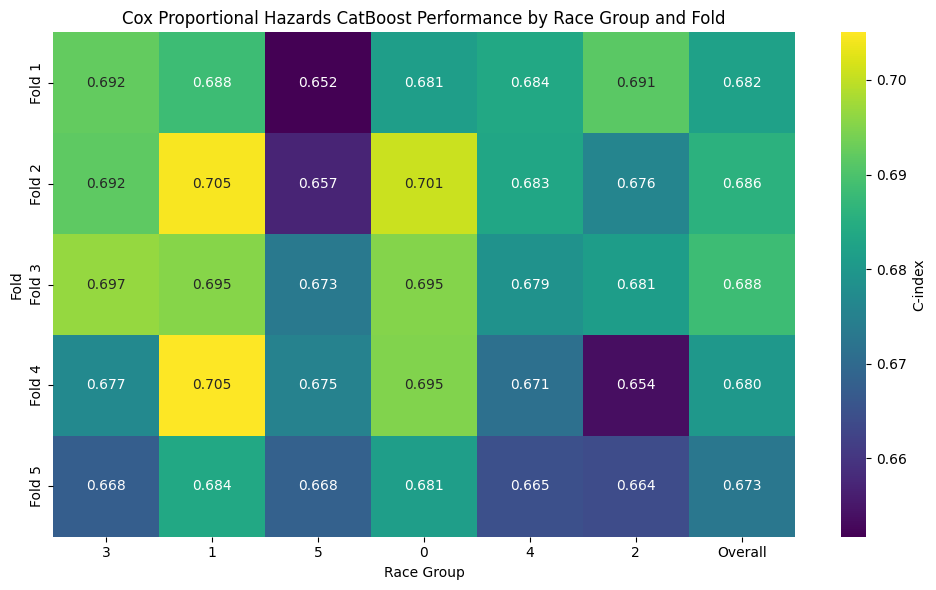


Mean C-index by Race Group:
  3: 0.685
  1: 0.695
  5: 0.665
  0: 0.691
  4: 0.676
  2: 0.673
  Overall Mean: 0.682

Standard Deviation of C-index by Race Group:
  3: 0.011
  1: 0.009
  5: 0.009
  0: 0.008
  4: 0.007
  2: 0.013
  Overall Std: 0.005


In [ ]:
cb_cox_params = {
    'loss_function': 'Cox',
    'grow_policy': 'SymmetricTree',
    'n_estimators': 800,
    'learning_rate': 0.092,
    'l2_leaf_reg': 2.5,
    'max_depth': 7,
    'colsample_bylevel': 0.84,
    'subsample': 0.9,
    'random_strength': 0.8,
    'verbose': False
}

all_fold_race_scores = {}
all_fold_overall_scores = []

for fold, (idx_tr, idx_va) in enumerate(kf.split(X_all, race_groups)):
    X_tr = X_all.iloc[idx_tr].copy()
    X_va = X_all.iloc[idx_va].copy()
    y_tr = y_surv[idx_tr]
    y_va = y_surv[idx_va]

    # prune cat_cols to only those in X_all
    cat_cols_filtered = [col for col in cat_cols if col in X_all.columns]

    model = CatBoostRegressor(**cb_cox_params, cat_features=cat_cols_filtered)
    model.fit(X_tr, y_tr)

    y_va_pred = model.predict(X_va)

    df_val = pd.DataFrame({'race_group': race_groups.iloc[idx_va].values})
    evaluate_fold(
        y_pred=y_va_pred,
        fold=fold,
        df_val=df_val,
        time=np.abs(y_va),
        event_observed=y_cls.iloc[idx_va].values
    )

display_overall("Cox Proportional Hazards CatBoost")


Fold 1:
  5: 0.599   3: 0.650   1: 0.644   0: 0.621   2: 0.641   4: 0.616   Overall: 0.629

Fold 2:
  3: 0.631   4: 0.625   1: 0.639   5: 0.611   2: 0.599   0: 0.644   Overall: 0.626

Fold 3:
  0: 0.651   5: 0.623   3: 0.624   4: 0.618   2: 0.617   1: 0.647   Overall: 0.632

Fold 4:
  1: 0.650   3: 0.610   5: 0.634   0: 0.648   2: 0.620   4: 0.629   Overall: 0.634

Fold 5:
  0: 0.612   4: 0.610   3: 0.613   5: 0.631   1: 0.634   2: 0.607   Overall: 0.620


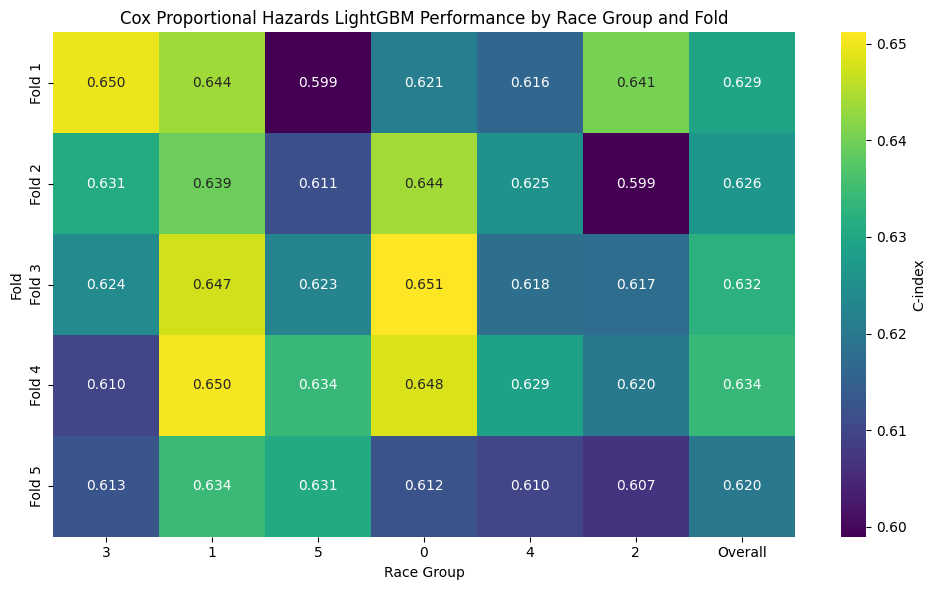


Mean C-index by Race Group:
  3: 0.625
  1: 0.643
  5: 0.620
  0: 0.635
  4: 0.620
  2: 0.617
  Overall Mean: 0.628

Standard Deviation of C-index by Race Group:
  3: 0.014
  1: 0.006
  5: 0.013
  0: 0.016
  4: 0.007
  2: 0.014
  Overall Std: 0.005


In [ ]:
lgbm_cox_params = {
    'objective': 'regression', # LightGBM lacks native survival support
    'metric': 'auc',
    'n_estimators': 800,
    'learning_rate': 0.02,
    'num_leaves': 31,
    'reg_alpha': 2.5,
    'reg_lambda': 2.5,
    'colsample_bytree': 0.84,
    'subsample': 0.9,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

all_fold_race_scores = {}
all_fold_overall_scores = []

for fold, (idx_tr, idx_va) in enumerate(kf.split(X_all, race_groups)):
    X_tr = X_all.iloc[idx_tr].copy()
    X_va = X_all.iloc[idx_va].copy()
    y_tr = y_surv[idx_tr]
    y_va = y_surv[idx_va]

    model = LGBMRegressor(**lgbm_cox_params)
    model.fit(X_tr, y_tr, categorical_feature=cat_cols_filtered)

    y_va_pred = model.predict(X_va)

    df_val = pd.DataFrame({'race_group': race_groups.iloc[idx_va].values})
    evaluate_fold(
        y_pred=y_va_pred,
        fold=fold,
        df_val=df_val,
        time=np.abs(y_va),
        event_observed=y_cls.iloc[idx_va].values
    )

display_overall("Cox Proportional Hazards LightGBM")


Fold 1:
  5: 0.561   3: 0.570   1: 0.589   0: 0.582   2: 0.590   4: 0.563   Overall: 0.575

Fold 2:
  3: 0.578   4: 0.575   1: 0.580   5: 0.577   2: 0.538   0: 0.567   Overall: 0.569

Fold 3:
  0: 0.599   5: 0.583   3: 0.561   4: 0.538   2: 0.553   1: 0.581   Overall: 0.569

Fold 4:
  1: 0.573   3: 0.561   5: 0.599   0: 0.589   2: 0.569   4: 0.572   Overall: 0.579

Fold 5:
  0: 0.568   4: 0.540   3: 0.550   5: 0.576   1: 0.563   2: 0.545   Overall: 0.558


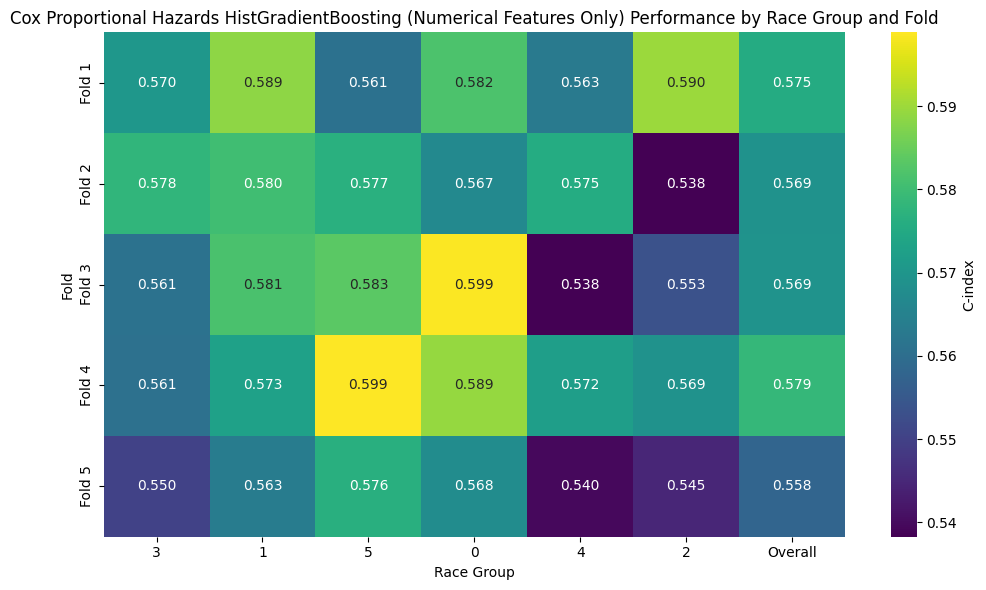


Mean C-index by Race Group:
  3: 0.564
  1: 0.577
  5: 0.579
  0: 0.581
  4: 0.558
  2: 0.559
  Overall Mean: 0.570

Standard Deviation of C-index by Race Group:
  3: 0.009
  1: 0.009
  5: 0.012
  0: 0.012
  4: 0.016
  2: 0.018
  Overall Std: 0.007


In [ ]:
y_surv = np.where(y_cls == 1, y_reg, -y_reg)
race_groups = processed['race_group']

# keep only numeric columns
numerical_features = X_all.select_dtypes(include='number').columns.tolist()
X_all_numeric = X_all[numerical_features]

# CV
all_fold_race_scores = {}
all_fold_overall_scores = []

hgb_cox_params = {
    'loss': 'squared_error',
    'learning_rate': 0.02,
    'max_iter': 800,
    'max_depth': 7,
    'l2_regularization': 2.5,
    'random_state': 42,
    'verbose': 0
}

for fold, (idx_tr, idx_va) in enumerate(kf.split(X_all_numeric, race_groups)):
    X_tr = X_all_numeric.iloc[idx_tr]
    X_va = X_all_numeric.iloc[idx_va]
    y_tr = y_surv[idx_tr]
    y_va = y_surv[idx_va]

    model = HistGradientBoostingRegressor(**hgb_cox_params)
    model.fit(X_tr, y_tr)

    y_va_pred = model.predict(X_va)

    df_val = pd.DataFrame({'race_group': race_groups.iloc[idx_va].values})
    evaluate_fold(
        y_pred=y_va_pred,
        fold=fold,
        df_val=df_val,
        time=np.abs(y_va),
        event_observed=y_cls.iloc[idx_va].values
    )

display_overall('Cox Proportional Hazards HistGradientBoosting (Numerical Features Only)')

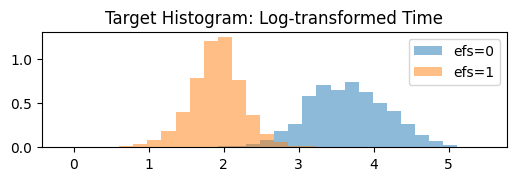

Modeling with target: log_efs_time

Fold 1:
  5: 0.113   3: 0.094   1: 0.098   0: 0.090   2: 0.104   4: 0.096   Overall: 0.100

Fold 2:
  3: 0.083   4: 0.097   1: 0.097   5: 0.120   2: 0.112   0: 0.094   Overall: 0.100

Fold 3:
  0: 0.093   5: 0.104   3: 0.085   4: 0.113   2: 0.111   1: 0.098   Overall: 0.101

Fold 4:
  1: 0.100   3: 0.087   5: 0.113   0: 0.090   2: 0.118   4: 0.106   Overall: 0.101

Fold 5:
  0: 0.095   4: 0.100   3: 0.089   5: 0.113   1: 0.111   2: 0.107   Overall: 0.102


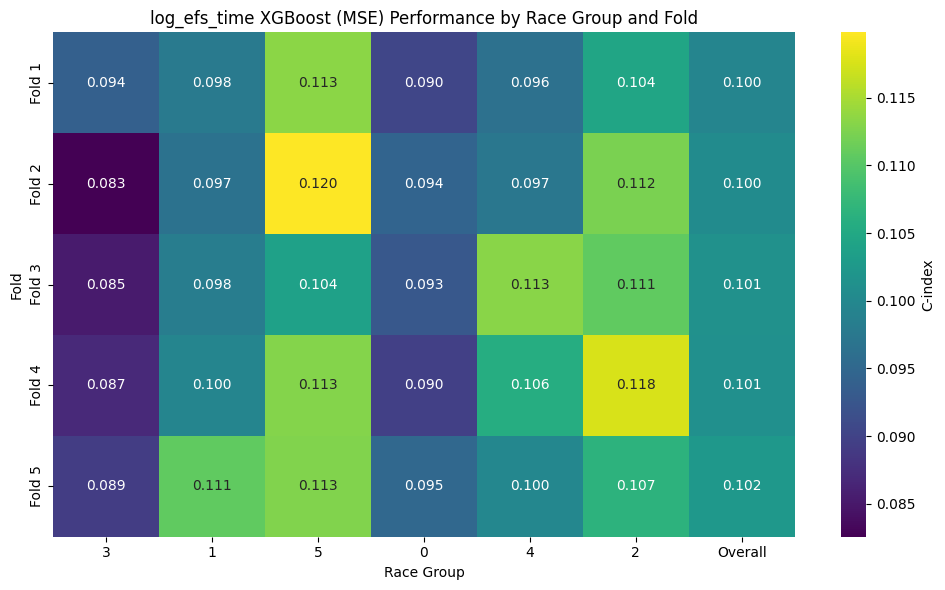


Mean C-index by Race Group:
  3: 0.088
  1: 0.101
  5: 0.113
  0: 0.092
  4: 0.102
  2: 0.110
  Overall Mean: 0.101

Standard Deviation of C-index by Race Group:
  3: 0.004
  1: 0.005
  5: 0.005
  0: 0.002
  4: 0.006
  2: 0.005
  Overall Std: 0.001



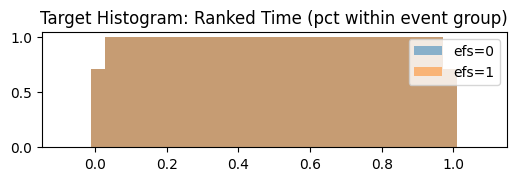

Modeling with target: ranked_efs_time

Fold 1:
  5: 0.378   3: 0.434   1: 0.400   0: 0.415   2: 0.406   4: 0.430   Overall: 0.412

Fold 2:
  3: 0.428   4: 0.428   1: 0.405   5: 0.361   2: 0.441   0: 0.439   Overall: 0.419

Fold 3:
  0: 0.403   5: 0.372   3: 0.437   4: 0.431   2: 0.419   1: 0.406   Overall: 0.414

Fold 4:
  1: 0.398   3: 0.451   5: 0.391   0: 0.416   2: 0.427   4: 0.402   Overall: 0.415

Fold 5:
  0: 0.428   4: 0.438   3: 0.430   5: 0.354   1: 0.398   2: 0.420   Overall: 0.414


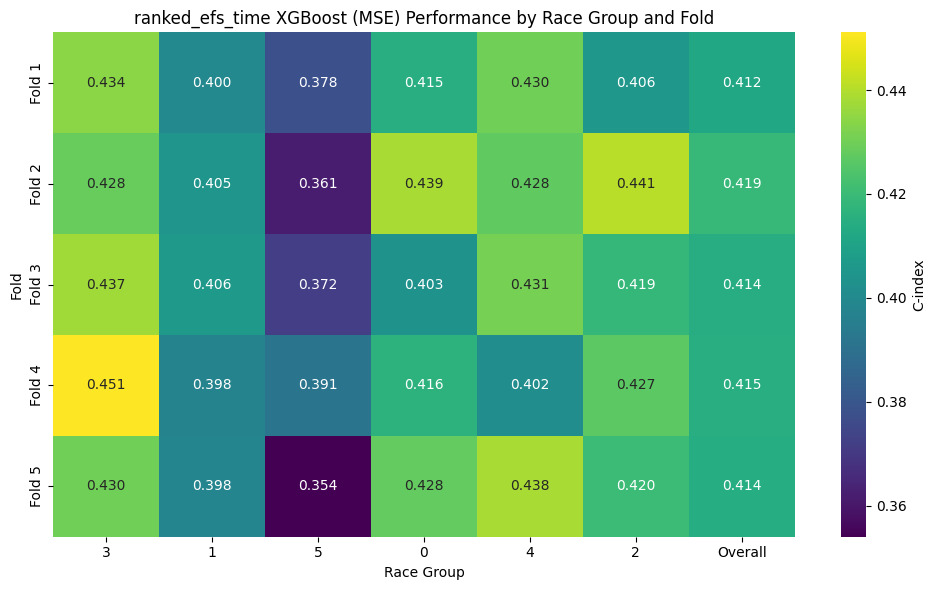


Mean C-index by Race Group:
  3: 0.436
  1: 0.401
  5: 0.371
  0: 0.420
  4: 0.426
  2: 0.422
  Overall Mean: 0.415

Standard Deviation of C-index by Race Group:
  3: 0.008
  1: 0.004
  5: 0.013
  0: 0.012
  4: 0.013
  2: 0.011
  Overall Std: 0.002



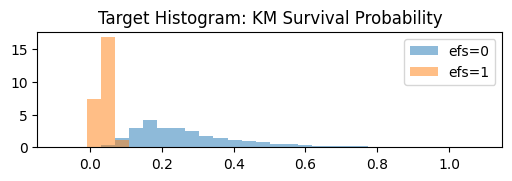

Modeling with target: km_survival_prob

Fold 1:
  5: 0.135   3: 0.107   1: 0.109   0: 0.113   2: 0.119   4: 0.109   Overall: 0.116

Fold 2:
  3: 0.092   4: 0.109   1: 0.106   5: 0.137   2: 0.126   0: 0.111   Overall: 0.114

Fold 3:
  0: 0.107   5: 0.132   3: 0.104   4: 0.132   2: 0.125   1: 0.119   Overall: 0.120

Fold 4:
  1: 0.120   3: 0.099   5: 0.129   0: 0.109   2: 0.134   4: 0.125   Overall: 0.119

Fold 5:
  0: 0.111   4: 0.111   3: 0.101   5: 0.130   1: 0.126   2: 0.124   Overall: 0.117


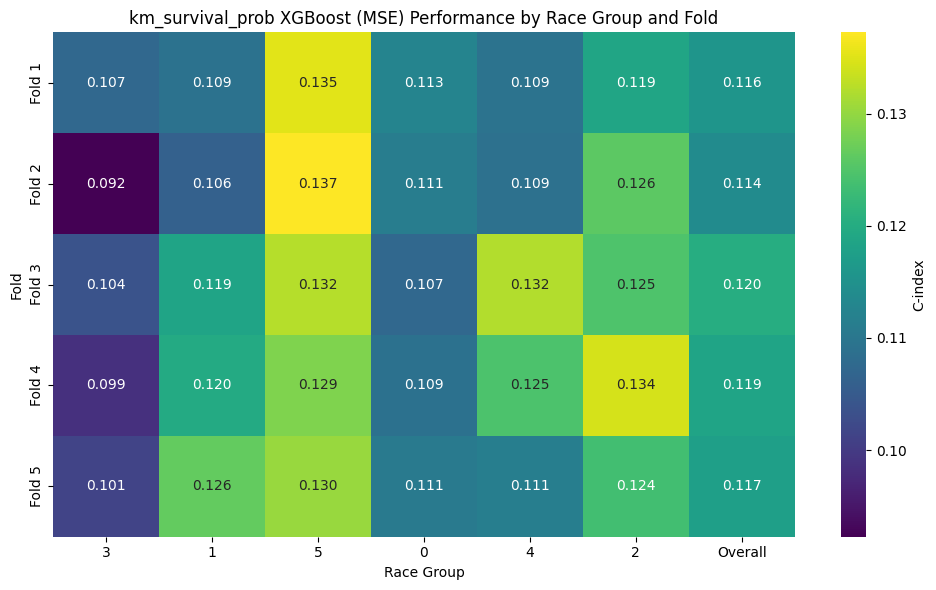


Mean C-index by Race Group:
  3: 0.101
  1: 0.116
  5: 0.133
  0: 0.110
  4: 0.117
  2: 0.126
  Overall Mean: 0.117

Standard Deviation of C-index by Race Group:
  3: 0.005
  1: 0.007
  5: 0.003
  0: 0.002
  4: 0.009
  2: 0.005
  Overall Std: 0.002



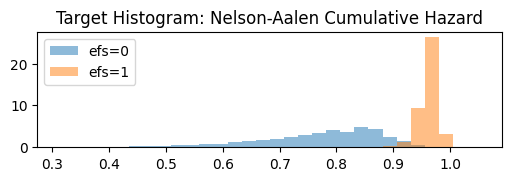

Modeling with target: na_cum_hazard

Fold 1:
  5: 0.872   3: 0.896   1: 0.894   0: 0.894   2: 0.884   4: 0.895   Overall: 0.889

Fold 2:
  3: 0.911   4: 0.896   1: 0.897   5: 0.869   2: 0.878   0: 0.893   Overall: 0.891

Fold 3:
  0: 0.897   5: 0.876   3: 0.900   4: 0.872   2: 0.879   1: 0.885   Overall: 0.884

Fold 4:
  1: 0.884   3: 0.906   5: 0.877   0: 0.897   2: 0.870   4: 0.881   Overall: 0.887

Fold 5:
  0: 0.894   4: 0.893   3: 0.903   5: 0.876   1: 0.880   2: 0.881   Overall: 0.888


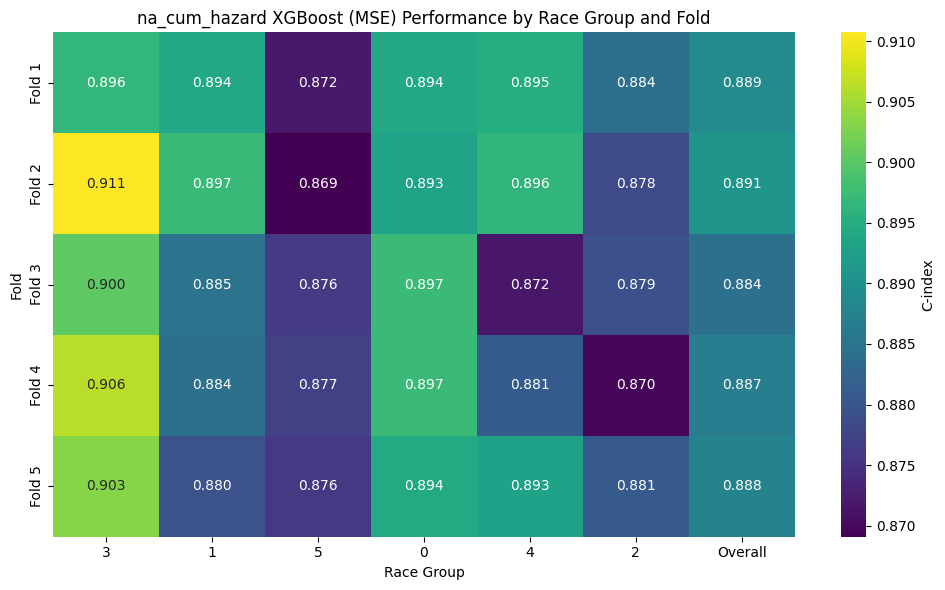


Mean C-index by Race Group:
  3: 0.903
  1: 0.888
  5: 0.874
  0: 0.895
  4: 0.887
  2: 0.878
  Overall Mean: 0.888

Standard Deviation of C-index by Race Group:
  3: 0.005
  1: 0.007
  5: 0.003
  0: 0.002
  4: 0.010
  2: 0.005
  Overall Std: 0.002



In [ ]:
# add back engineered target columns
df_train = processed['X'].copy()
df_train['efs'] = processed['efs']
df_train['efs_time'] = processed['efs_time']
df_train['race_group'] = processed['race_group']
df_train['efs_as_feat'] = df_train['efs'].astype(int)
sample_weights = np.where(df_train["efs"] == 1, 0.6, 0.4) 

# add engineered targets (KM, log time, hazard, etc.)
df_train = fe.prepare_targets(df_train, model_type='tree', train=True)

# identify features (dropping known target leakage cols)
drop_leaky_cols = ['efs', 'efs_time', 'log_efs_time', 'ranked_efs_time',
                   'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard',
                   'target_norm', 'ID', 'race_group', 'km_true', 'na_true']
features = [col for col in df_train.columns if col not in drop_leaky_cols]
# Now df_train will have log_efs_time, ranked_efs_time, km_survival_prob, etc.

targets_to_plot = {
    "log_efs_time": "Log-transformed Time",
    "ranked_efs_time": "Ranked Time (pct within event group)",
    "km_survival_prob": "KM Survival Probability",
    "na_cum_hazard": "Nelson-Aalen Cumulative Hazard", 
}

for col, label in targets_to_plot.items():
    plt.figure(figsize=(6, 1.5))
    values = df_train[col].values
    vmin, vmax = 1.09 * values.min() - 0.09 * values.max(), 1.09 * values.max() - 0.09 * values.min()
    plt.hist(values[df_train.efs == 0], bins=np.linspace(vmin, vmax, 31), density=True, alpha=0.5, label="efs=0")
    plt.hist(values[df_train.efs == 1], bins=np.linspace(vmin, vmax, 31), density=True, alpha=0.5, label="efs=1")
    plt.title(f"Target Histogram: {label}")
    plt.legend()
    plt.show()

    print(f"Modeling with target: {col}")
    
    all_fold_race_scores = {}
    all_fold_overall_scores = []

    for fold, (idx_tr, idx_va) in enumerate(kf.split(df_train, df_train.race_group)):
        X_tr = df_train.iloc[idx_tr][features].copy()
        X_va = df_train.iloc[idx_va][features].copy()
        y_tr = df_train.iloc[idx_tr][col]
        w_tr = sample_weights[idx_tr]

        # object columns are converted to categorical for XGBoost
        for df_part in [X_tr, X_va]:
            obj_cols = df_part.select_dtypes(include='object').columns
            for obj_col in obj_cols:
                df_part[obj_col] = df_part[obj_col].astype('category')

        model = xgboost.XGBRegressor(objective='reg:squarederror', # MSE loss
                                     max_depth=3, 
                                     colsample_bytree=0.5,  
                                     subsample=0.8,  
                                     n_estimators=2000,  
                                     learning_rate=0.02,  
                                     enable_categorical=True,
                                     min_child_weight=80)
        
        
        model.fit(X_tr, y_tr, sample_weight=w_tr)
        y_va_pred = model.predict(X_va)
        evaluate_fold(y_pred=y_va_pred, fold=fold, df_val=df_train.iloc[idx_va], time=df_train.iloc[idx_va].efs_time.values, event_observed=df_train.iloc[idx_va].efs.values)
    
    display_overall(f"{col} XGBoost (MSE)")
    print()